# Analysis of North American Natural Gas Futures

This project take a look through a statistical lense at NA natural gas futures.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, DateFormatter
import seaborn as sns

In [3]:
def read_file_futures_data(filename, year):
    
    # Making a dictionary of dataframes
    df_dict = {}
    
    df = pd.read_excel(filename, header = None, sheet_name = year)
        
    # Dropping full NaN rows and columns
    df = df.dropna(axis = 1, how = 'all')
    df = df.dropna(axis = 0, how = 'all')
        
    # Getting a list of contract names
    contract_names = df.iloc[0, ::2]
    contract_names = list(contract_names)
        
    # Dropping first row that contains header
    df = df.drop(0)
        
    for ele in contract_names:
            
        # Creating an index to obtain every two columns for each corresponding contract month
        index_int = contract_names.index(ele)
        month_df = df.iloc[:, index_int * 2:index_int * 2 + 2]
            
        # Data cleaning for new dataframe
        month_df.columns = ['Date', 'Price']
        month_df = month_df.dropna(axis = 0, how = 'all')
        month_df['Date'] = pd.to_datetime(month_df['Date'], format='%m/%d/%y')
            
        # Making dataframe the value and contract name the key
        df_dict[ele] = month_df
    
    return df_dict

In [4]:
prices_2018 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2018')
prices_2019 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2019')
prices_2020 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2020')
prices_2021 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2021')
prices_2022 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2022')
prices_2023 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2023')
prices_2024 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2024')
prices_2025 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2025')
prices_2026 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2026')
prices_2027 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2027')
prices_2028 = read_file_futures_data('natgas_price_data_copyval.xlsx', '2028')

In [5]:
def read_file_spot_data(filename):
    
    df_dict = {}
    df = pd.read_excel(filename, header = None)
    df = df.iloc[:, 0:2]
    df = df.drop(0)
    df.columns = ['Date', 'Price']
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
    df = df.dropna(axis = 1, how = 'all')
    df = df.dropna(axis = 0, how = 'all')
    df_dict['HH Index'] = df
    
    return df_dict

In [6]:
spot_prices = read_file_spot_data('spot_price_data.xlsx')

In [7]:
def data_visualization_prices(price1, contract1, price2, contract2):
    
    merged_df = pd.merge(price1[contract1], price2[contract2], on = 'Date', suffixes = ('_1', '_2'))
    
    # Create figure and axis objects
    fig, ax = plt.subplots(figsize = (12, 6))
    
    # Plot both series from merged dataframe
    ax.plot(merged_df['Date'], merged_df['Price_1'], label = contract1, color = 'blue')
    ax.plot(merged_df['Date'], merged_df['Price_2'], label = contract2, color = 'red')
    
    # Format axis
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth = [1, 6]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    
    # Customization
    plt.title(contract1 + ' vs ' + contract2)
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.setp(ax.get_xticklabels(), rotation = 45, ha ='right')
    plt.tight_layout()
    
    plt.show()

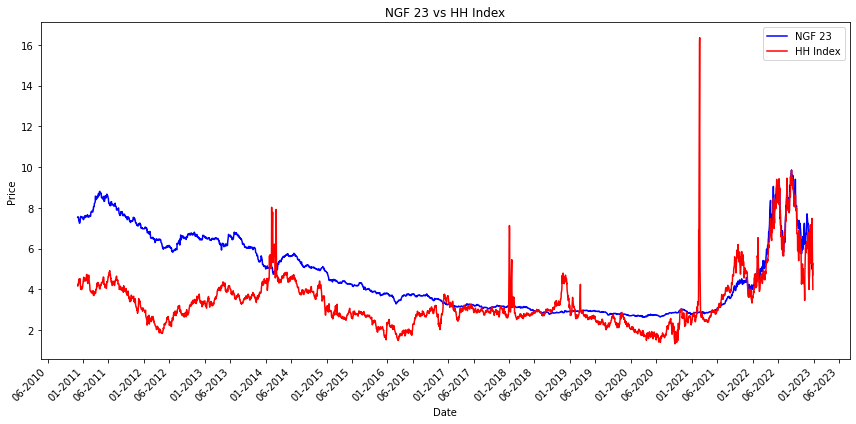

In [8]:
data_visualization_prices(prices_2023, 'NGF 23', spot_prices, 'HH Index')

In [9]:
def corr_covar_matrix(prices_dict1, prices_dict2, timespan):

    df1 = pd.DataFrame()
    df2 = pd.DataFrame()
    
    # Fill first dataframe
    first_contract = list(prices_dict1.keys())[0]
    df1['Date'] = pd.to_datetime(prices_dict1[first_contract]['Date'])
    for contract in prices_dict1.keys():
        df1[contract] = prices_dict1[contract]['Price']
        
    # Fill second dataframe
    first_contract = list(prices_dict2.keys())[0]
    df2['Date'] = pd.to_datetime(prices_dict2[first_contract]['Date'])
    for contract in prices_dict2.keys():
        df2[contract] = prices_dict2[contract]['Price']
        
    same_dict = prices_dict1 is prices_dict2
    
    # Merging
    if same_dict:
        merged_df = df1.copy()
    else:
        merged_df = pd.merge(df1, df2, on = 'Date', how = 'inner', 
                            suffixes = ('_1', '_2'))
    
    # Filtering for a time period
    months = int(timespan * 12)
    most_recent_date = merged_df['Date'].max()
    start_date = most_recent_date - pd.DateOffset(months = months)
    merged_df = merged_df[(merged_df['Date'] >= start_date)]
    
    # Calculate matrices excluding Date column
    corr_matrix = merged_df.drop('Date', axis = 1).corr()
    cov_matrix = merged_df.drop('Date', axis = 1).cov()
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Correlation heatmap
    sns.heatmap(corr_matrix, 
                ax = ax1,
                annot = True, 
                fmt = '.2f',
                cmap = 'coolwarm',
                center = 0,
                vmin = -1,
                vmax = 1,
                annot_kws = {'size': 8})
    ax1.set_title(f'Correlation Matrix - {months} Month Lookback')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation = 45, ha = 'right')
    
    # Covariance heatmap
    sns.heatmap(cov_matrix,
                ax = ax2,
                annot = True,
                fmt = '.2f',
                cmap = 'coolwarm',
                center = 0,
                annot_kws = {'size': 8})
    ax2.set_title(f'Covariance Matrix - {months} Month Lookback')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation = 45, ha = 'right')
    
    plt.tight_layout()
    
    print(f"Corr & Covar Matrix Date Range: {merged_df['Date'].min().strftime('%m/%d/%Y')} to {merged_df['Date'].max().strftime('%m/%d/%Y')}")
    
    return corr_matrix, cov_matrix, fig

Corr & Covar Matrix Date Range: 12/29/2020 to 12/29/2021


(          NGF 22    NGG 22    NGH 22    NGJ 22    NGK 22    NGM 22    NGN 22  \
 NGF 22  1.000000  0.999876  0.998522  0.943123  0.923423  0.921599  0.919485   
 NGG 22  0.999876  1.000000  0.998909  0.943679  0.924049  0.922249  0.920155   
 NGH 22  0.998522  0.998909  1.000000  0.954380  0.936843  0.935272  0.933434   
 NGJ 22  0.943123  0.943679  0.954380  1.000000  0.998333  0.997957  0.997514   
 NGK 22  0.923423  0.924049  0.936843  0.998333  1.000000  0.999956  0.999853   
 NGM 22  0.921599  0.922249  0.935272  0.997957  0.999956  1.000000  0.999965   
 NGN 22  0.919485  0.920155  0.933434  0.997514  0.999853  0.999965  1.000000   
 NGQ 22  0.917989  0.918675  0.932086  0.997241  0.999786  0.999925  0.999986   
 NGU 22  0.917070  0.917770  0.931242  0.997092  0.999746  0.999891  0.999957   
 NGV 22  0.916353  0.917071  0.930662  0.996916  0.999686  0.999843  0.999924   
 NGX 22  0.912182  0.912949  0.927080  0.995745  0.999208  0.999484  0.999671   
 NGZ 22  0.906358  0.907197 

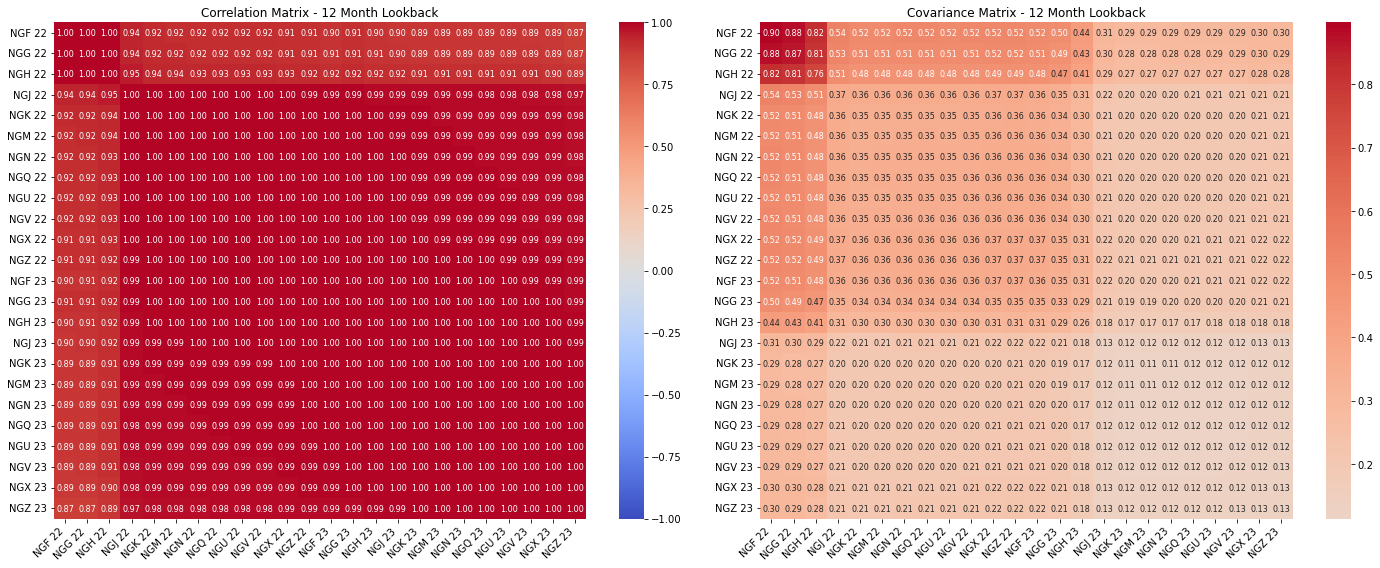

In [10]:
corr_covar_matrix(prices_2022, prices_2023, 1)

In [11]:
def compare_two_contracts(prices_dict1, prices_dict2, contract1_name, contract2_name, time):
    # Get the two contract dataframes
    contract1_df = prices_dict1[contract1_name].copy()
    contract2_df = prices_dict2[contract2_name].copy()

    # Making a merged df on date
    merged_df = pd.merge(contract1_df, contract2_df, on = 'Date', how = 'inner', suffixes=('_1', '_2'))
    
    # Getting a timeframe for comparison
    most_recent_date = merged_df['Date'].max()
    two_years_prior = most_recent_date - pd.DateOffset(years = time)
    merged_df = merged_df[merged_df['Date'] >= two_years_prior]
    
    # Calculating correlation
    correlation = merged_df['Price_1'].corr(merged_df['Price_2'])
    
    print(f"Correlation between {contract1_name} and {contract2_name}: {correlation:.3f}")
    print(f"Date range: {merged_df['Date'].min().strftime('%m/%d/%Y')} to {merged_df['Date'].max().strftime('%m/%d/%Y')}")

In [12]:
compare_two_contracts(prices_2023, prices_2024, 'NGF 23', 'NGZ 24', 1)

Correlation between NGF 23 and NGZ 24: 0.790
Date range: 12/28/2021 to 12/28/2022


In [13]:
def hist_vol_and_log_returns(prices_dict, window):
    
    plt.figure(figsize=(20, 10))
    
    for contract, df in prices_dict.items():
        
        df['log_returns'] = np.log(df['Price'] / df['Price'].shift(1))
        df['daily_vol'] = df['log_returns'].std()
        df['annualized_vol'] = df['daily_vol'] * np.sqrt(252)
        df['trailing_vol'] = df['log_returns'].rolling(window = window).std() * np.sqrt(252)
    
        plt.plot(df['Date'], df['trailing_vol'], label = contract)
       
    # Customization
    plt.title(f'Trailing Volitility ({window} day window)')
    plt.xlabel('Year')
    plt.ylabel('Trailing Vol')
    plt.gca().xaxis.set_major_locator(YearLocator())
    plt.gca().xaxis.set_major_formatter(DateFormatter('%Y'))  
    plt.legend(title = 'Contracts')
    plt.tight_layout()
    plt.show()
     
    for contract, df in prices_dict.items():
        
        mean = round(df['log_returns'].mean(), 2)
        skew = round(df['log_returns'].skew(), 2)
        kurtosis = round(df['log_returns'].kurtosis(), 2)
        
        
        # Customization
        plt.figure(figsize=(8, 4))
        sns.kdeplot(df['log_returns'])
        #plt.hist(df['log_returns'], bins = 150, color = 'blue')
        plt.title(f'{contract} Log Returns Distribution')
        plt.xlabel('Log Returns')
        plt.ylabel('Frequency')
        plt.show()
        
        print(str(contract) + ' Annualized Volatility: ' + str(round(df['annualized_vol'].iloc[3] * 100, 2)) + '%, Mean: ' + str(mean) + ', Skew: ' + str(skew) + ', Kurtosis: ' + str(kurtosis))
        

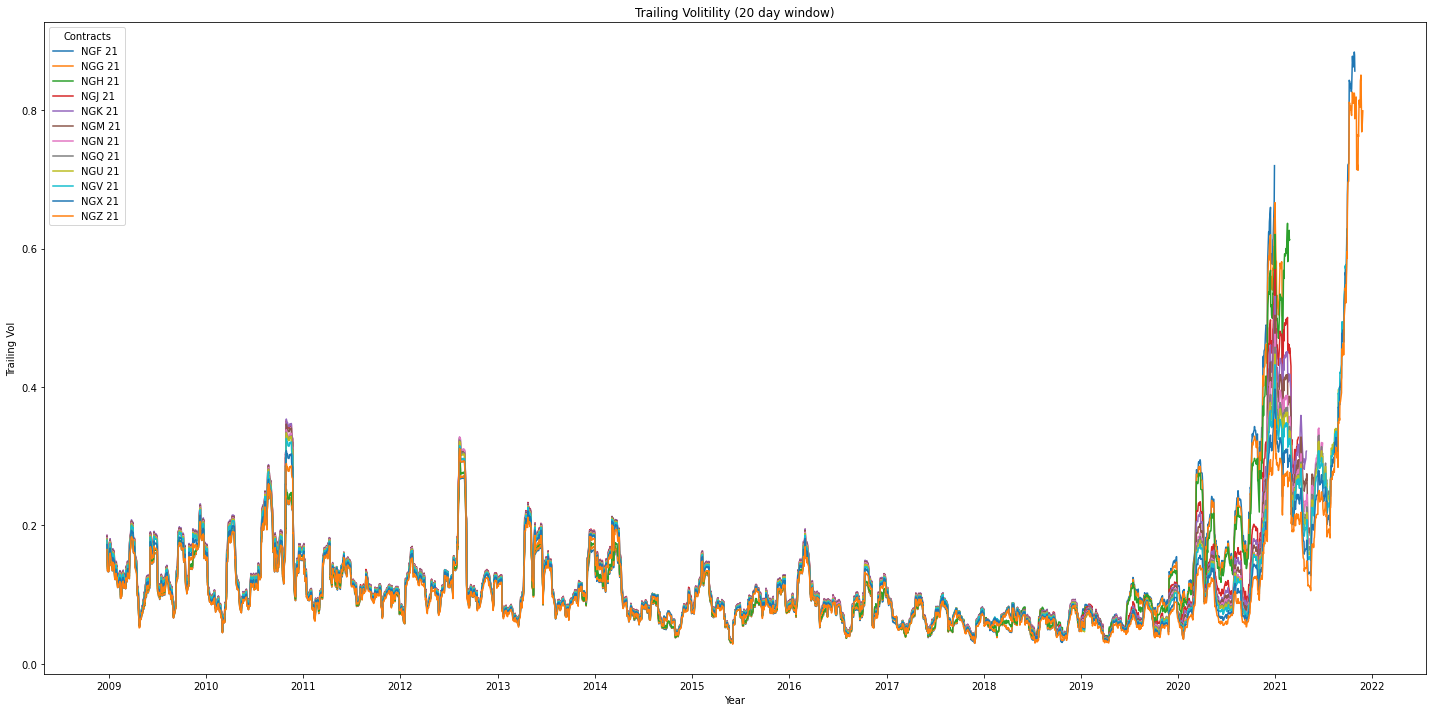

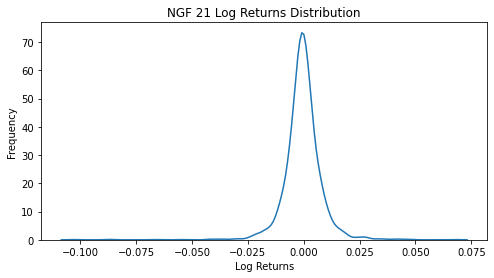

NGF 21 Annualized Volatility: 13.61%, Mean: -0.0, Skew: -1.16, Kurtosis: 20.48


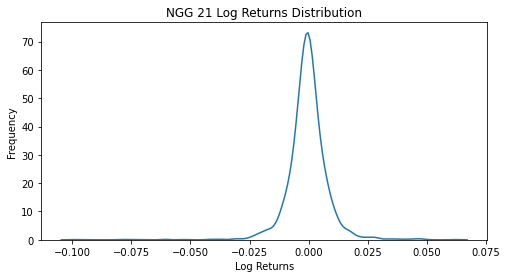

NGG 21 Annualized Volatility: 13.77%, Mean: -0.0, Skew: -0.85, Kurtosis: 17.29


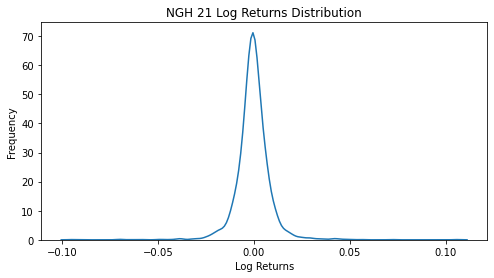

NGH 21 Annualized Volatility: 14.23%, Mean: -0.0, Skew: 0.12, Kurtosis: 19.19


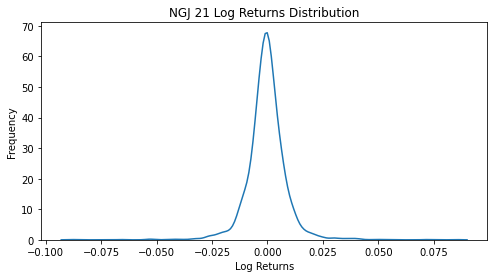

NGJ 21 Annualized Volatility: 14.1%, Mean: -0.0, Skew: 0.13, Kurtosis: 12.38


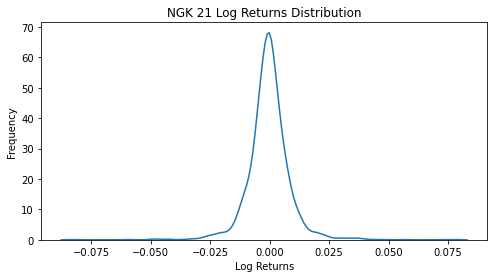

NGK 21 Annualized Volatility: 13.95%, Mean: -0.0, Skew: 0.15, Kurtosis: 10.58


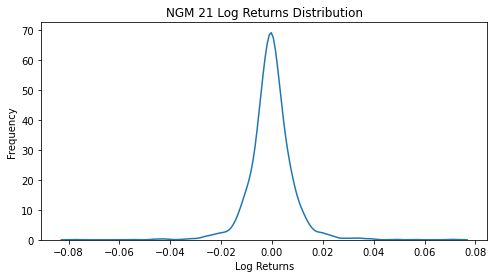

NGM 21 Annualized Volatility: 13.68%, Mean: -0.0, Skew: 0.19, Kurtosis: 9.59


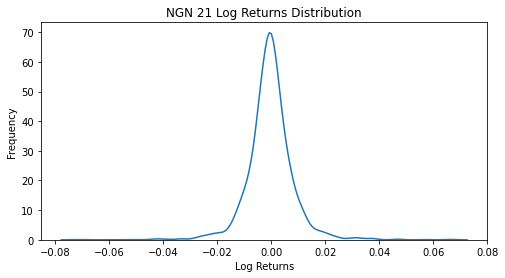

NGN 21 Annualized Volatility: 13.56%, Mean: -0.0, Skew: 0.28, Kurtosis: 8.52


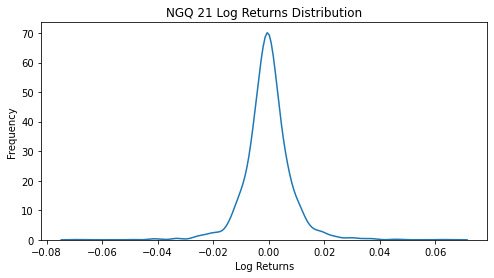

NGQ 21 Annualized Volatility: 13.46%, Mean: -0.0, Skew: 0.28, Kurtosis: 7.73


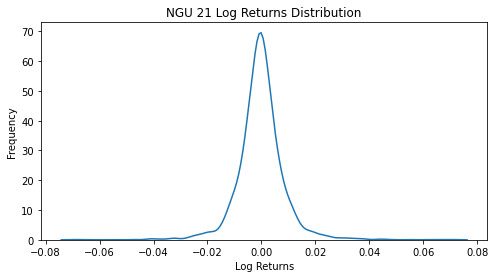

NGU 21 Annualized Volatility: 13.72%, Mean: -0.0, Skew: 0.44, Kurtosis: 8.41


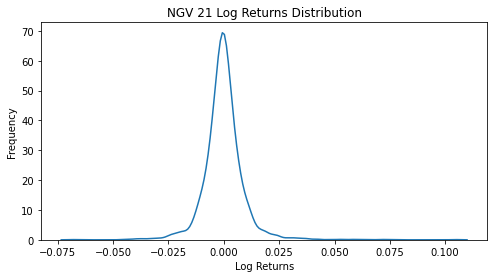

NGV 21 Annualized Volatility: 14.39%, Mean: -0.0, Skew: 1.09, Kurtosis: 13.79


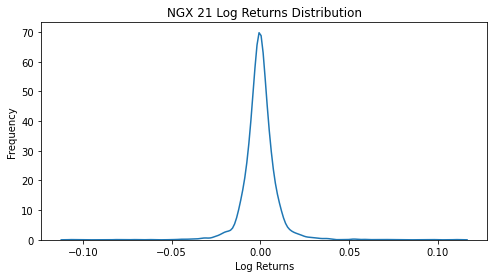

NGX 21 Annualized Volatility: 15.4%, Mean: -0.0, Skew: 0.86, Kurtosis: 23.27


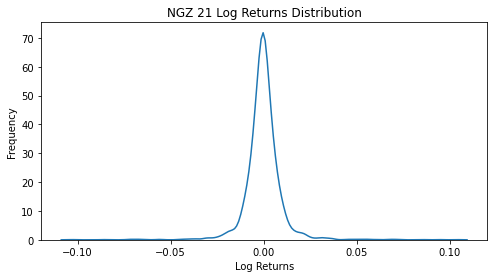

NGZ 21 Annualized Volatility: 15.84%, Mean: -0.0, Skew: 0.34, Kurtosis: 22.52


In [14]:
hist_vol_and_log_returns(prices_2021, 20)